## CMAPSS Predictive Maintenance Pipeline
### Bronze layer

In [0]:
from pyspark.sql.types import StructType, StructField, DoubleType, IntegerType
from pyspark.sql.functions import lit

### Column Schema Definition

In [0]:
# Column names based on NASA README documentation
# 26 columns: 2 identifiers + 3 operational settings + 21 sensor measurements

TRAIN_TEST_COLUMNS = [
  "unit_id",            # Engine unit number
  "cycle",              # Time in cycles
  "op_setting_1",       # Operational setting 1
  "op_setting_2",
  "op_setting_3",
]

for i in range(21):
  TRAIN_TEST_COLUMNS.append(f"sensor_{i+1}")

RUL_COLUMNS = ["rul_true"] # True RUL at last observed cycle

DATASETS = ["FD001", "FD002", "FD003", "FD004"]

VOLUME_PATH = "/Volumes/cmapss_project/source_raw/raw_files"


### Ingest Train Files

In [0]:
for dataset_id in DATASETS:
  file_path = f"{VOLUME_PATH}/train_{dataset_id}.txt"
  table_name = f"cmapss_project.bronze.bronze_train_{dataset_id.lower()}"
  print(f"Ingesting: {file_path}")
  
  df = (
    spark.read
    .format("csv")
    .option("sep", " ")
    .option("header", "false")
    .option("inferSchema", "true")
    .load(file_path)
  )

  # Drop the last 2 empty null columns
  df = df.drop("_c26", "_c27")

  df = df.toDF(*TRAIN_TEST_COLUMNS)

  # Add metadata columns
  df = (
    df.withColumn("dataset_id", lit(dataset_id))
    .withColumn("data_split", lit("train"))
  )

  (
    df.write
    .format("delta")
    .mode("overwrite")
    .saveAsTable(table_name)
  )

  
  print(f"Written to: {table_name} | Rows: {df.count()}")



Ingesting: /Volumes/cmapss_project/source_raw/raw_files/train_FD001.txt
Written to: cmapss_project.bronze.bronze_train_fd001 | Rows: 20631
Ingesting: /Volumes/cmapss_project/source_raw/raw_files/train_FD002.txt
Written to: cmapss_project.bronze.bronze_train_fd002 | Rows: 53759
Ingesting: /Volumes/cmapss_project/source_raw/raw_files/train_FD003.txt
Written to: cmapss_project.bronze.bronze_train_fd003 | Rows: 24720
Ingesting: /Volumes/cmapss_project/source_raw/raw_files/train_FD004.txt
Written to: cmapss_project.bronze.bronze_train_fd004 | Rows: 61249


### Ingest Test Files

In [0]:
for dataset_id in DATASETS:
    file_path = f"{VOLUME_PATH}/test_{dataset_id}.txt"
    table_name = f"cmapss_project.bronze.bronze_test_{dataset_id.lower()}"

    print(f"Ingesting: {file_path}")

    df = (
        spark.read
        .format("csv")
        .option("sep", " ")
        .option("header", "false")
        .option("inferSchema", "true")
        .load(file_path)
    )

    # Drop the last 2 empty null columns
    df = df.drop("_c26", "_c27")

    df = df.toDF(*TRAIN_TEST_COLUMNS)

    # Add metadata columns
    df = (
        df.withColumn("dataset_id", lit(dataset_id))
        .withColumn("data_split", lit("test"))
    )

    (
        df.write
        .format("delta")
        .mode("overwrite")
        .saveAsTable(table_name)
    )

    print(f"Written to: {table_name} | Rows: {df.count()}")

Ingesting: /Volumes/cmapss_project/source_raw/raw_files/test_FD001.txt
Written to: cmapss_project.bronze.bronze_test_fd001 | Rows: 13096
Ingesting: /Volumes/cmapss_project/source_raw/raw_files/test_FD002.txt
Written to: cmapss_project.bronze.bronze_test_fd002 | Rows: 33991
Ingesting: /Volumes/cmapss_project/source_raw/raw_files/test_FD003.txt
Written to: cmapss_project.bronze.bronze_test_fd003 | Rows: 16596
Ingesting: /Volumes/cmapss_project/source_raw/raw_files/test_FD004.txt
Written to: cmapss_project.bronze.bronze_test_fd004 | Rows: 41214


### Ingest RUL Ground Truth Files

In [0]:
for dataset_id in DATASETS:
  file_path = f"{VOLUME_PATH}/RUL_{dataset_id}.txt"
  table_name = f"cmapss_project.bronze.bronze_rul_{dataset_id.lower()}"

  print(f"Ingesting: {file_path}")

  df = (
    spark.read
    .format("csv")
    .option("sep", " ")
    .option("header", "false")
    .option("inferSchema", "true")
    .load(file_path)
  )

  df = df.select("_c0").toDF("rul_true")
  from pyspark.sql.functions import monotonically_increasing_id
  df = df.withColumn("unit_id", monotonically_increasing_id() + 1)
  df = df.withColumn("dataset_id", lit(dataset_id))
  
  (
    df.write
    .format("delta")
    .mode("overwrite")
    .saveAsTable(table_name)
  )

  print(f"Written to: {table_name} | Rows: {df.count()}")


Ingesting: /Volumes/cmapss_project/source_raw/raw_files/RUL_FD001.txt
Written to: cmapss_project.bronze.bronze_rul_fd001 | Rows: 100
Ingesting: /Volumes/cmapss_project/source_raw/raw_files/RUL_FD002.txt
Written to: cmapss_project.bronze.bronze_rul_fd002 | Rows: 259
Ingesting: /Volumes/cmapss_project/source_raw/raw_files/RUL_FD003.txt
Written to: cmapss_project.bronze.bronze_rul_fd003 | Rows: 100
Ingesting: /Volumes/cmapss_project/source_raw/raw_files/RUL_FD004.txt
Written to: cmapss_project.bronze.bronze_rul_fd004 | Rows: 248


### EDA: Bronze Train Table

In [0]:
for dataset_id in DATASETS:
  table_name = f"cmapss_project.bronze.bronze_train_{dataset_id.lower()}"
  df = spark.read.format("delta").table(table_name)

  print(f"\n{'=' * 10} DATASET: {dataset_id} {'=' * 10}")
  print(f"Shape: {df.count()} rows x {len(df.columns)} columns")
  print(f"\nSchema")
  df.printSchema()
  print(f"\nSample rows:")
  display(df.limit(5))
 





========== DATASET: FD001 ==========
Shape: 20631 rows x 28 columns

Schema
root
 |-- unit_id: integer (nullable = true)
 |-- cycle: integer (nullable = true)
 |-- op_setting_1: double (nullable = true)
 |-- op_setting_2: double (nullable = true)
 |-- op_setting_3: double (nullable = true)
 |-- sensor_1: double (nullable = true)
 |-- sensor_2: double (nullable = true)
 |-- sensor_3: double (nullable = true)
 |-- sensor_4: double (nullable = true)
 |-- sensor_5: double (nullable = true)
 |-- sensor_6: double (nullable = true)
 |-- sensor_7: double (nullable = true)
 |-- sensor_8: double (nullable = true)
 |-- sensor_9: double (nullable = true)
 |-- sensor_10: double (nullable = true)
 |-- sensor_11: double (nullable = true)
 |-- sensor_12: double (nullable = true)
 |-- sensor_13: double (nullable = true)
 |-- sensor_14: double (nullable = true)
 |-- sensor_15: double (nullable = true)
 |-- sensor_16: double (nullable = true)
 |-- sensor_17: integer (nullable = true)
 |-- sensor_18: int

unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset_id,data_split
1,1,-7.0E-4,-4.0E-4,100.0,518.67,641.82,1589.7,1400.6,14.62,21.61,554.36,2388.06,9046.19,1.3,47.47,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.419,FD001,train
1,2,0.0019,-3.0E-4,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,553.75,2388.04,9044.07,1.3,47.49,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.0,23.4236,FD001,train
1,3,-0.0043,3.0E-4,100.0,518.67,642.35,1587.99,1404.2,14.62,21.61,554.26,2388.08,9052.94,1.3,47.27,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,FD001,train
1,4,7.0E-4,0.0,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,554.45,2388.11,9049.48,1.3,47.13,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,FD001,train
1,5,-0.0019,-2.0E-4,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,554.0,2388.06,9055.15,1.3,47.28,522.19,2388.04,8133.8,8.4294,0.03,393,2388,100.0,38.9,23.4044,FD001,train



========== DATASET: FD002 ==========
Shape: 53759 rows x 28 columns

Schema
root
 |-- unit_id: integer (nullable = true)
 |-- cycle: integer (nullable = true)
 |-- op_setting_1: double (nullable = true)
 |-- op_setting_2: double (nullable = true)
 |-- op_setting_3: double (nullable = true)
 |-- sensor_1: double (nullable = true)
 |-- sensor_2: double (nullable = true)
 |-- sensor_3: double (nullable = true)
 |-- sensor_4: double (nullable = true)
 |-- sensor_5: double (nullable = true)
 |-- sensor_6: double (nullable = true)
 |-- sensor_7: double (nullable = true)
 |-- sensor_8: double (nullable = true)
 |-- sensor_9: double (nullable = true)
 |-- sensor_10: double (nullable = true)
 |-- sensor_11: double (nullable = true)
 |-- sensor_12: double (nullable = true)
 |-- sensor_13: double (nullable = true)
 |-- sensor_14: double (nullable = true)
 |-- sensor_15: double (nullable = true)
 |-- sensor_16: double (nullable = true)
 |-- sensor_17: integer (nullable = true)
 |-- sensor_18: int

unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset_id,data_split
1,1,34.9983,0.84,100.0,449.44,555.32,1358.61,1137.23,5.48,8.0,194.64,2222.65,8341.91,1.02,42.02,183.06,2387.72,8048.56,9.3461,0.02,334,2223,100.0,14.73,8.8071,FD002,train
1,2,41.9982,0.8408,100.0,445.0,549.9,1353.22,1125.78,3.91,5.71,138.51,2211.57,8303.96,1.02,42.2,130.42,2387.66,8072.3,9.3774,0.02,330,2212,100.0,10.41,6.2665,FD002,train
1,3,24.9988,0.6218,60.0,462.54,537.31,1256.76,1047.45,7.05,9.02,175.71,1915.11,8001.42,0.94,36.69,164.22,2028.03,7864.87,10.8941,0.02,309,1915,84.93,14.08,8.6723,FD002,train
1,4,42.0077,0.8416,100.0,445.0,549.51,1354.03,1126.38,3.91,5.71,138.46,2211.58,8303.96,1.02,41.96,130.72,2387.61,8068.66,9.3528,0.02,329,2212,100.0,10.59,6.4701,FD002,train
1,5,25.0005,0.6203,60.0,462.54,537.07,1257.71,1047.93,7.05,9.03,175.05,1915.1,7993.23,0.94,36.89,164.31,2028.0,7861.23,10.8963,0.02,309,1915,84.93,14.13,8.5286,FD002,train



========== DATASET: FD003 ==========
Shape: 24720 rows x 28 columns

Schema
root
 |-- unit_id: integer (nullable = true)
 |-- cycle: integer (nullable = true)
 |-- op_setting_1: double (nullable = true)
 |-- op_setting_2: double (nullable = true)
 |-- op_setting_3: double (nullable = true)
 |-- sensor_1: double (nullable = true)
 |-- sensor_2: double (nullable = true)
 |-- sensor_3: double (nullable = true)
 |-- sensor_4: double (nullable = true)
 |-- sensor_5: double (nullable = true)
 |-- sensor_6: double (nullable = true)
 |-- sensor_7: double (nullable = true)
 |-- sensor_8: double (nullable = true)
 |-- sensor_9: double (nullable = true)
 |-- sensor_10: double (nullable = true)
 |-- sensor_11: double (nullable = true)
 |-- sensor_12: double (nullable = true)
 |-- sensor_13: double (nullable = true)
 |-- sensor_14: double (nullable = true)
 |-- sensor_15: double (nullable = true)
 |-- sensor_16: double (nullable = true)
 |-- sensor_17: integer (nullable = true)
 |-- sensor_18: int

unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset_id,data_split
1,1,-5.0E-4,4.0E-4,100.0,518.67,642.36,1583.23,1396.84,14.62,21.61,553.97,2387.96,9062.17,1.3,47.3,522.31,2388.01,8145.32,8.4246,0.03,391,2388,100.0,39.11,23.3537,FD003,train
1,2,8.0E-4,-3.0E-4,100.0,518.67,642.5,1584.69,1396.89,14.62,21.61,554.55,2388.0,9061.78,1.3,47.23,522.42,2388.03,8152.85,8.4403,0.03,392,2388,100.0,38.99,23.4491,FD003,train
1,3,-0.0014,-2.0E-4,100.0,518.67,642.18,1582.35,1405.61,14.62,21.61,554.43,2388.03,9070.23,1.3,47.22,522.03,2388.0,8150.17,8.3901,0.03,391,2388,100.0,38.85,23.3669,FD003,train
1,4,-0.002,1.0E-4,100.0,518.67,642.92,1585.61,1392.27,14.62,21.61,555.21,2388.0,9064.57,1.3,47.24,522.49,2388.08,8146.56,8.3878,0.03,392,2388,100.0,38.96,23.2951,FD003,train
1,5,0.0016,0.0,100.0,518.67,641.68,1588.63,1397.65,14.62,21.61,554.74,2388.04,9076.14,1.3,47.15,522.58,2388.03,8147.8,8.3869,0.03,392,2388,100.0,39.14,23.4583,FD003,train



========== DATASET: FD004 ==========
Shape: 61249 rows x 28 columns

Schema
root
 |-- unit_id: integer (nullable = true)
 |-- cycle: integer (nullable = true)
 |-- op_setting_1: double (nullable = true)
 |-- op_setting_2: double (nullable = true)
 |-- op_setting_3: double (nullable = true)
 |-- sensor_1: double (nullable = true)
 |-- sensor_2: double (nullable = true)
 |-- sensor_3: double (nullable = true)
 |-- sensor_4: double (nullable = true)
 |-- sensor_5: double (nullable = true)
 |-- sensor_6: double (nullable = true)
 |-- sensor_7: double (nullable = true)
 |-- sensor_8: double (nullable = true)
 |-- sensor_9: double (nullable = true)
 |-- sensor_10: double (nullable = true)
 |-- sensor_11: double (nullable = true)
 |-- sensor_12: double (nullable = true)
 |-- sensor_13: double (nullable = true)
 |-- sensor_14: double (nullable = true)
 |-- sensor_15: double (nullable = true)
 |-- sensor_16: double (nullable = true)
 |-- sensor_17: integer (nullable = true)
 |-- sensor_18: int

unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset_id,data_split
1,1,42.0049,0.84,100.0,445.0,549.68,1343.43,1112.93,3.91,5.7,137.36,2211.86,8311.32,1.01,41.69,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.0,10.62,6.367,FD004,train
1,2,20.002,0.7002,100.0,491.19,606.07,1477.61,1237.5,9.35,13.61,332.1,2323.66,8713.6,1.07,43.94,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.0,24.37,14.6552,FD004,train
1,3,42.0038,0.8409,100.0,445.0,548.95,1343.12,1117.05,3.91,5.69,138.18,2211.92,8306.69,1.01,41.66,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.0,10.48,6.4213,FD004,train
1,4,42.0,0.84,100.0,445.0,548.7,1341.24,1118.03,3.91,5.7,137.98,2211.88,8312.35,1.02,41.68,129.8,2388.02,8076.05,9.3369,0.02,328,2212,100.0,10.54,6.4176,FD004,train
1,5,25.0063,0.6207,60.0,462.54,536.1,1255.23,1033.59,7.05,9.0,174.82,1915.22,7994.94,0.93,36.48,164.11,2028.08,7865.8,10.8366,0.02,305,1915,84.93,14.03,8.6754,FD004,train


### EDA: Check for Nulls

In [0]:
from pyspark.sql.functions import col, sum as spark_sum

for dataset_id in DATASETS:
  table_name = f"cmapss_project.bronze.bronze_train_{dataset_id.lower()}"
  df = spark.read.format("delta").table(table_name)

  null_counts = df.select([
    spark_sum(col(c).isNull().cast("int")).alias(c)
    for c in df.columns
  ])
  print(f"\nNull counts for {dataset_id}:")
  display(null_counts)


Null counts for FD001:


unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset_id,data_split
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Null counts for FD002:


unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset_id,data_split
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Null counts for FD003:


unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset_id,data_split
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Null counts for FD004:


unit_id,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,dataset_id,data_split
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


### EDA: Detect Constant Sensors

In [0]:
# Find sensors with zero or near-zero variance
# These carry no predictive signal and will be dropped in Silver

from pyspark.sql.functions import stddev

sensor_cols = [f"sensor_{i+1}" for i in range(21)]

for dataset_id in DATASETS:
  table_name = f"cmapss_project.bronze.bronze_train_{dataset_id.lower()}"
  df = spark.read.format("delta").table(table_name)

  print(f"\nSensor standard deviations - {dataset_id}:")
  std_df = df.select([stddev(col(c))
                      .alias(c)
                      for c in sensor_cols])
  display(std_df, truncate=False)


Sensor standard deviations - FD001:


sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
2.8639569852075244E-11,0.5000532700605442,6.131149519690886,9.000604780543732,1.004046812327384E-12,0.001388984912707458,0.8850922576634341,0.07098547889106986,22.082879525067316,9.945688791667424E-14,0.26708739863968733,0.7375533922096779,0.0719189156988659,19.076175975952662,0.037505037951967,9.509692969913915E-16,1.548763024614299,0.0,0.0,0.18074642787365977,0.10825087474491306



Sensor standard deviations - FD002:


sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
26.389707310759263,37.28939902046242,105.9463406139554,119.1234275853244,3.613838818550971,5.431801597465509,146.0053061400598,145.2098160683498,335.8120126761641,0.1274688477562662,3.232372058786374,137.65950694989536,128.06827104323722,84.83794969298563,0.749335492232489,0.004711473795965321,27.754515422961237,145.32798014258134,5.364066520346025,9.86933120069957,5.921615208351725



Sensor standard deviations - FD003:


sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
2.8642250113784562E-11,0.5230311380084658,6.810418054769298,9.77317832738765,1.0039585419076794E-12,0.01811600004848827,3.4373428742748566,0.1582849283522052,19.980294309113425,0.0034848490401651858,0.30007416142324944,3.2553139774429054,0.15812066988936024,16.50411768269025,0.06051161367848661,9.509943376750044E-16,1.761458507096321,0.0,0.0,0.2488646946032772,0.14923378801551307



Sensor standard deviations - FD004:


sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,sensor_10,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
26.436831642865908,37.34264670176505,106.16759773766968,119.32759068781476,3.6228721173763283,5.444016543155812,146.88020952321904,145.34824288738037,336.92754654344185,0.12768052859258358,3.2434915349889795,138.47910916306927,128.1978592492214,85.67054344902132,0.7503736864794557,0.004684705613381079,27.808283453502003,145.4724911914696,5.3694236389083265,9.936396142937783,5.962697250948249


EDA results on sensor standard deviation: sensors with std = 0 or <0.001
- FD001 : ['sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
- FD002 : None
- FD003: ['sensor_1', 'sensor_5', 'sensor_16', 'sensor_18', 'sensor_19']
- FD004: None

### EDA: Sensor Trend for One Engine

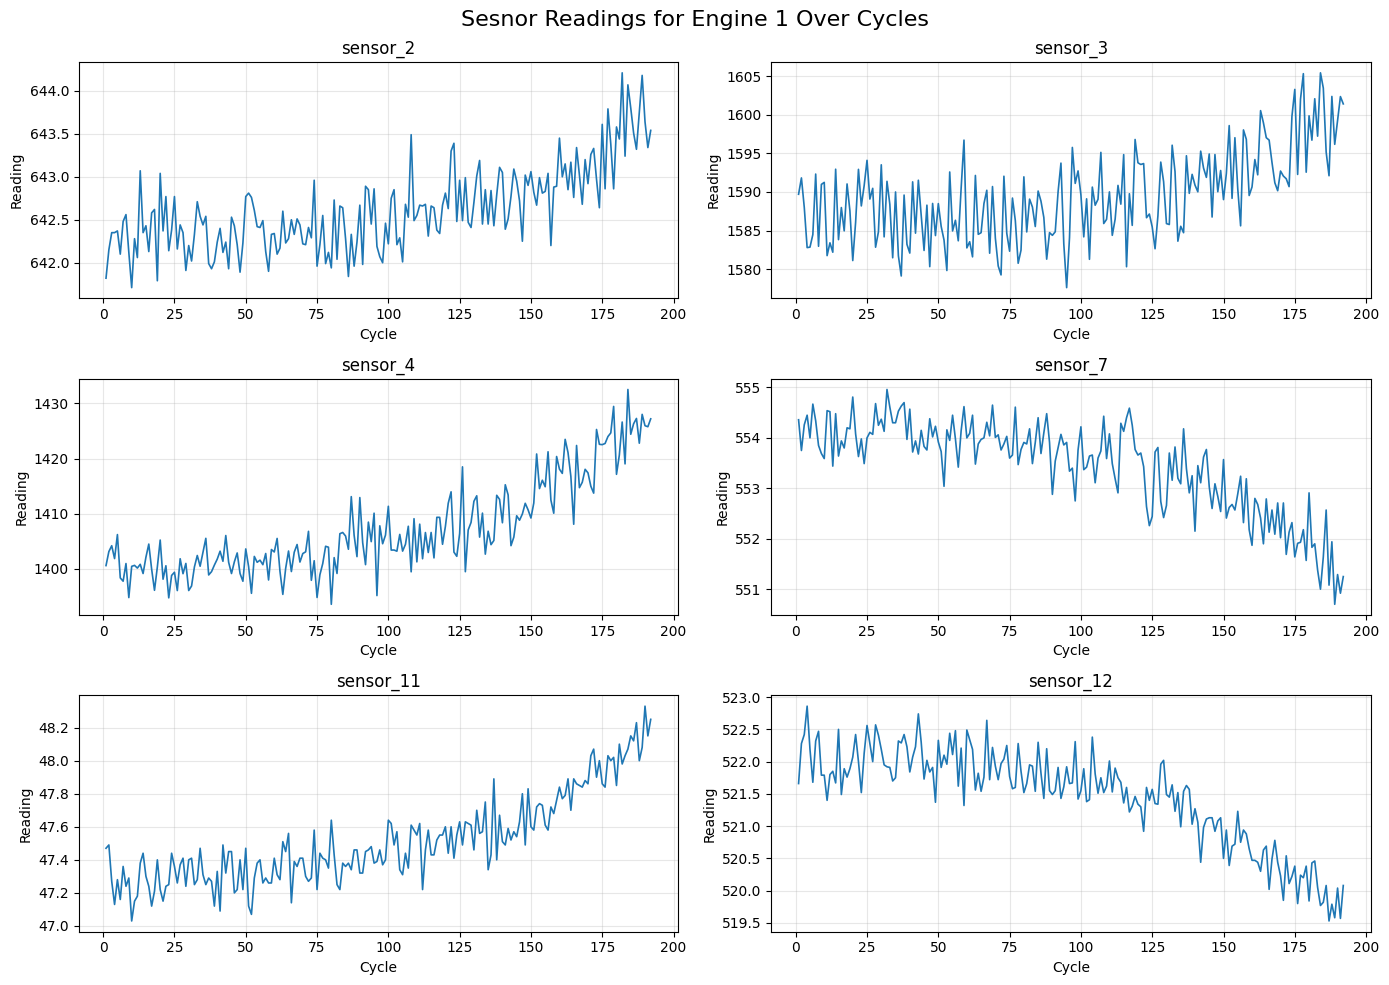

In [0]:
# Plot sensor readings over cycles for one engine

import matplotlib.pyplot as plt
import pandas as pd

dataset_id = "FD001"
table_name = f"cmapss_project.bronze.bronze_train_{dataset_id.lower()}"
df = spark.read.format("delta").table(table_name)

engine_1 = df.filter(col("unit_id") == 1).orderBy("cycle").toPandas()

# Sensors with some significant variance
sensors_to_plot = ["sensor_2", "sensor_3", "sensor_4", "sensor_7", "sensor_11", "sensor_12"]

fig, axes = plt.subplots(3, 2, figsize=(14,10))
fig.suptitle("Sesnor Readings for Engine 1 Over Cycles", fontsize=16)
for ax, sensor in zip(axes.flatten(), sensors_to_plot):
  ax.plot(engine_1["cycle"], engine_1[sensor], linewidth=1.2)
  ax.set_title(sensor)
  ax.set_xlabel("Cycle")
  ax.set_ylabel("Reading")
  ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### EDA: Engine Lifespan Distribution

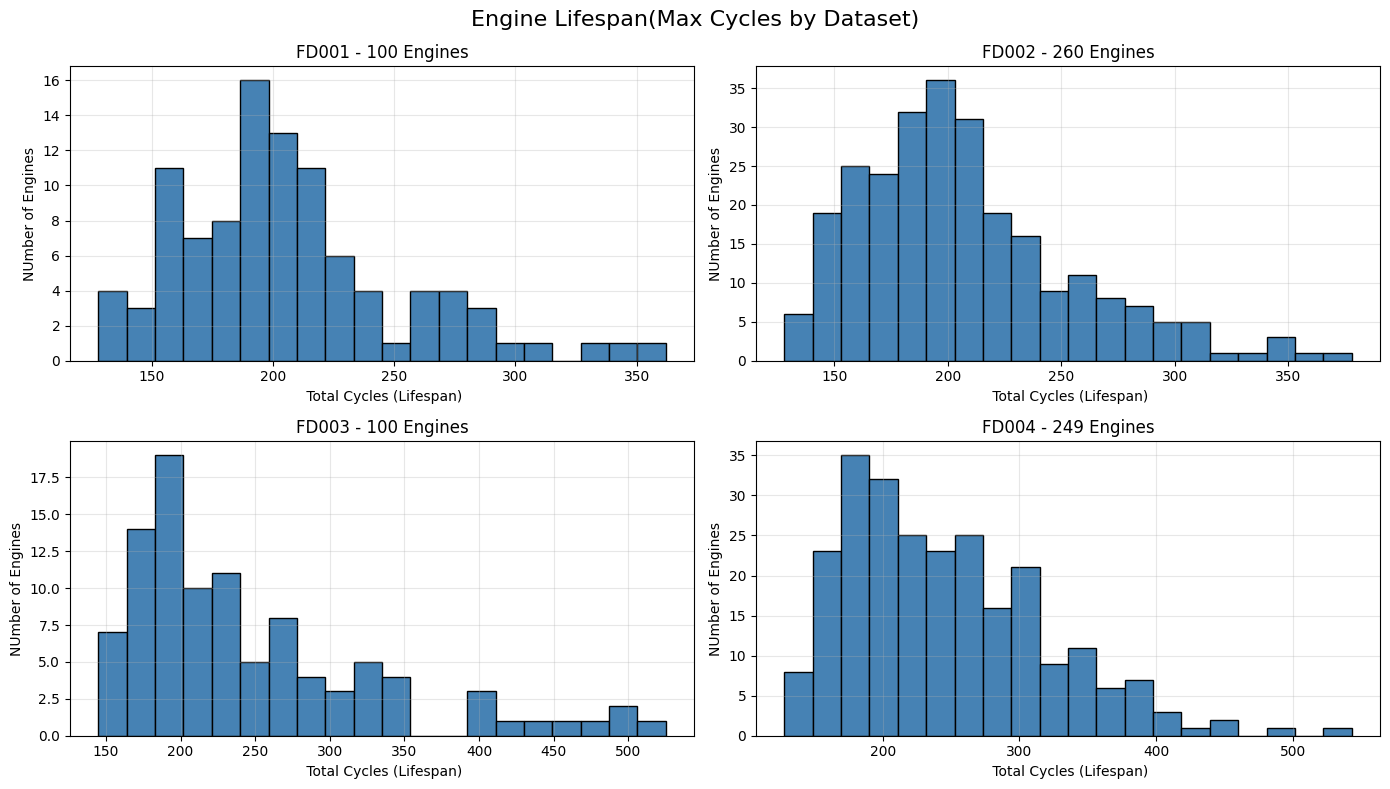

In [0]:
# How long do the engines last across each dataset
# To understand the RUL distrubution

from pyspark.sql.functions import max as spark_max

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Engine Lifespan(Max Cycles by Dataset)", fontsize=16)

for ax, dataset_id in zip(axes.flatten(), DATASETS):
  table_name = f"cmapss_project.bronze.bronze_train_{dataset_id.lower()}"
  df = spark.read.format("delta").table(table_name)

  lifespan = (
    df.groupBy("unit_id")
    .agg(spark_max(col("cycle")).alias("max_cycle"))
    .toPandas()
  )

  ax.hist(lifespan["max_cycle"], bins=20, edgecolor="black", color="steelblue")
  ax.set_title(f"{dataset_id} - {len(lifespan)} Engines")
  ax.set_xlabel(" Total Cycles (Lifespan)")
  ax.set_ylabel("NUmber of Engines")
  ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()